Idea:

Train NeuMF on user-item dataset and predict ratings. Add neuMF calculations to the metadata dataset and train an XGBoost with all the features for the final prediction.

Metrics: RMSE, Precision@k, Recall@K

In [58]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.utils.data as data
import kagglehub
import matplotlib.pyplot as plt
from collections import defaultdict
from xgboost import XGBRegressor, XGBRanker
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
class NeuMFDataset(data.Dataset):
    def __init__(self, users, items, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.items = torch.tensor(items, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [3]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=32, mlp_dims=(64, 32, 16, 8), dropout=0.2):
        super().__init__()

        # GMF part
        self.user_gmf = nn.Embedding(num_users, emb_dim)
        self.item_gmf = nn.Embedding(num_items, emb_dim)

        # MLP part
        self.user_mlp = nn.Embedding(num_users, emb_dim)
        self.item_mlp = nn.Embedding(num_items, emb_dim)

        mlp_layers = []
        input_dim = emb_dim * 2
        for d in mlp_dims:
            mlp_layers += [nn.Linear(input_dim, d), nn.ReLU(), nn.Dropout(dropout)]
            input_dim = d
        self.mlp = nn.Sequential(*mlp_layers)

        # Final layer
        self.output = nn.Linear(emb_dim + mlp_dims[-1], 1)

    def forward(self, user_ids, item_ids):
        ug = self.user_gmf(user_ids)
        ig = self.item_gmf(item_ids)
        gmf_out = ug * ig

        um = self.user_mlp(user_ids)
        im = self.item_mlp(item_ids)
        mlp_out = self.mlp(torch.cat([um, im], dim=-1))

        x = torch.cat([gmf_out, mlp_out], dim=-1)
        pred = self.output(x).squeeze(-1)
        return pred

    def get_features(self, user_ids, item_ids):
        with torch.no_grad():
            ug = self.user_gmf(user_ids)
            ig = self.item_gmf(item_ids)
            um = self.user_mlp(user_ids)
            im = self.item_mlp(item_ids)

            gmf_out = ug * ig
            mlp_out = self.mlp(torch.cat([um, im], dim=-1))
            pred = self.output(torch.cat([gmf_out, mlp_out], dim=-1)).squeeze(-1)

            return {
                "user_gmf": ug,
                "item_gmf": ig,
                "user_mlp": um,
                "item_mlp": im,
                "gmf_out": gmf_out,
                "mlp_out": mlp_out,
                "pred": pred
            }

In [4]:
def train_neumf(model, train_loader, val_loader, epochs=10, lr=1e-3, device="cuda"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_func = nn.MSELoss()

    best_val_rmse = float("inf")
    best_state = None
    history = {"train_rmse": [], "val_rmse": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for user_ids, item_ids, ratings in train_loader:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            ratings = ratings.float().to(device)

            optimizer.zero_grad()
            preds = model(user_ids, item_ids)
            loss = loss_func(preds, ratings)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(ratings)

        train_rmse = (total_loss / len(train_loader.dataset)) ** 0.5
        val_rmse = evaluate_rmse(model, val_loader, device=device)

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1}: train_rmse={train_rmse:.4f} val_rmse={val_rmse:.4f}")

    model.load_state_dict(best_state)
    return model, history

def evaluate_rmse(model, data_loader, device="cuda"):
    model.eval()
    preds_all = []
    y_all = []

    with torch.no_grad():
        for user_ids, item_ids, ratings in data_loader:
            user_ids = user_ids.to(device)
            item_ids = item_ids.to(device)
            ratings = ratings.float().to(device)

            preds = model(user_ids, item_ids)
            preds_all.append(preds.cpu())
            y_all.append(ratings.cpu())

    preds_all = torch.cat(preds_all)
    y_all = torch.cat(y_all)
    rmse = torch.sqrt(torch.mean((preds_all - y_all) ** 2)).item()
    return rmse

In [10]:
def build_hybrid_features(df, model, user_col, item_col, meta_cols, device="cuda", batch_size=4096):
    model.eval()
    rows = []

    user_arr = df[user_col].to_numpy()
    item_arr = df[item_col].to_numpy()

    for start in range(0, len(df), batch_size):
        end = min(start + batch_size, len(df))

        user_ids = torch.tensor(user_arr[start:end], dtype=torch.long, device=device)
        item_ids = torch.tensor(item_arr[start:end], dtype=torch.long, device=device)

        feats = model.get_features(user_ids, item_ids)

        block = {
            "neumf_pred": feats["pred"].cpu().numpy(),
        }

        for name in ["user_gmf", "item_gmf", "user_mlp", "item_mlp", "gmf_out", "mlp_out"]:
            arr = feats[name].cpu().numpy()
            for j in range(arr.shape[1]):
                block[f"{name}_{j}"] = arr[:, j]

        rows.append(pd.DataFrame(block))

    nn_df = pd.concat(rows, ignore_index=True)
    out = pd.concat([df.reset_index(drop=True)[meta_cols], nn_df], axis=1)
    return out

In [6]:
user_item_df = pd.read_csv("user_item.csv")
num_users = user_item_df["user"].nunique()
num_items = user_item_df["item"].nunique()

train_val_df, test_df = train_test_split(
    user_item_df,
    test_size=0.2,
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42
)

train_dataset = NeuMFDataset(
    users=train_df["user"].values,
    items=train_df["item"].values,
    ratings=train_df["rating"].values
)

val_dataset = NeuMFDataset(
    users=val_df["user"].values,
    items=val_df["item"].values,
    ratings=val_df["rating"].values
)

test_dataset = NeuMFDataset(
    users=test_df["user"].values,
    items=test_df["item"].values,
    ratings=test_df["rating"].values
)

train_loader = data.DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=256, shuffle=False)

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

neumf = NeuMF(num_users=num_users, num_items=num_items)
trained_neumf, history = train_neumf(
    model=neumf,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=4,
    device=device
)

test_rmse = evaluate_rmse(trained_neumf, test_loader, device=device)
print("Test RMSE:", test_rmse)

Epoch 1: train_rmse=3.2036 val_rmse=1.7755
Epoch 2: train_rmse=2.2589 val_rmse=1.7081
Epoch 3: train_rmse=2.1004 val_rmse=1.6663
Epoch 4: train_rmse=1.9678 val_rmse=1.5689
Test RMSE: nan


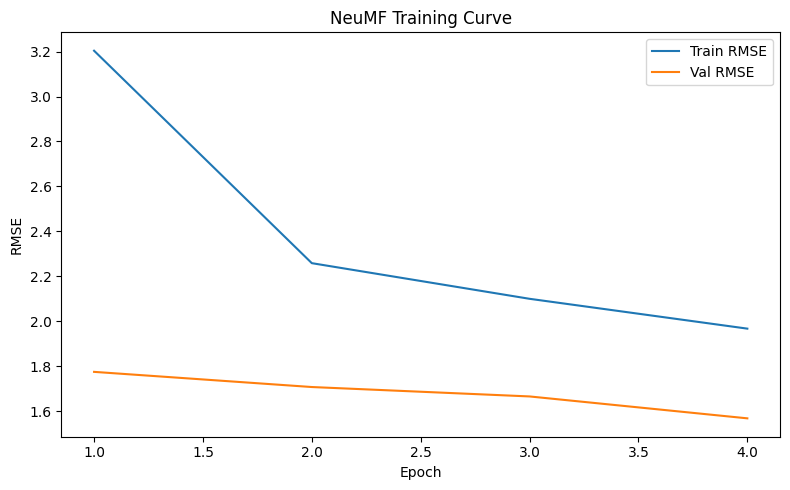

In [8]:
epochs = range(1, len(history["train_rmse"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_rmse"], label="Train RMSE")
plt.plot(epochs, history["val_rmse"], label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("NeuMF Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
path = kagglehub.dataset_download("threnjen/board-games-database-from-boardgamegeek")

user_item_df = pd.read_csv("user_item.csv")
meta_data    = pd.read_csv("df.csv")

user_ratings = pd.read_csv(f"{path}/user_ratings.csv")
item_to_id   = {item: idx for idx, item in enumerate(user_ratings["BGGId"].unique())}
id_to_item   = {v: k for k, v in item_to_id.items()}

bggid_sorted = sorted(user_ratings["BGGId"].unique())
meta_data["BGGId"] = bggid_sorted
meta_data["item"]  = meta_data["BGGId"].map(item_to_id)

merged = user_item_df.merge(meta_data.drop(columns=["BGGId"]), on="item", how="left")

meta_cols = [c for c in merged.columns if c not in ["user", "item", "rating"]]

Using Colab cache for faster access to the 'board-games-database-from-boardgamegeek' dataset.


In [61]:
df_hybrid = build_hybrid_features(
    merged,
    trained_neumf,
    user_col="user",
    item_col="item",
    meta_cols=meta_cols,
    device=device,
    batch_size=4096
)

y = merged["rating"].values

X_train, X_temp, y_train, y_temp = train_test_split(df_hybrid, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = X_train[col].astype('category')
for col in X_val.select_dtypes(include=['object']).columns:
    X_val[col] = X_val[col].astype('category')
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype('category')

In [47]:
# RMSE xgb with neuMF

xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    enable_categorical=True
)

xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_train,y_train),(X_val, y_val)],
    verbose=50
)

val_pred  = xgb_reg.predict(X_val)
val_rmse  = np.sqrt(mean_squared_error(y_val, val_pred))
print("Validation RMSE:", val_rmse)

[0]	validation_0-rmse:1.68760	validation_1-rmse:1.70266
[50]	validation_0-rmse:1.08048	validation_1-rmse:1.10016
[100]	validation_0-rmse:1.04939	validation_1-rmse:1.07486
[150]	validation_0-rmse:1.03562	validation_1-rmse:1.06875
[200]	validation_0-rmse:1.02465	validation_1-rmse:1.06521
[250]	validation_0-rmse:1.01530	validation_1-rmse:1.06272
[300]	validation_0-rmse:1.00678	validation_1-rmse:1.06098
[350]	validation_0-rmse:0.99888	validation_1-rmse:1.05975
[400]	validation_0-rmse:0.99199	validation_1-rmse:1.05887
[450]	validation_0-rmse:0.98487	validation_1-rmse:1.05773
[499]	validation_0-rmse:0.97880	validation_1-rmse:1.05718
Validation RMSE: 1.0571805014983076


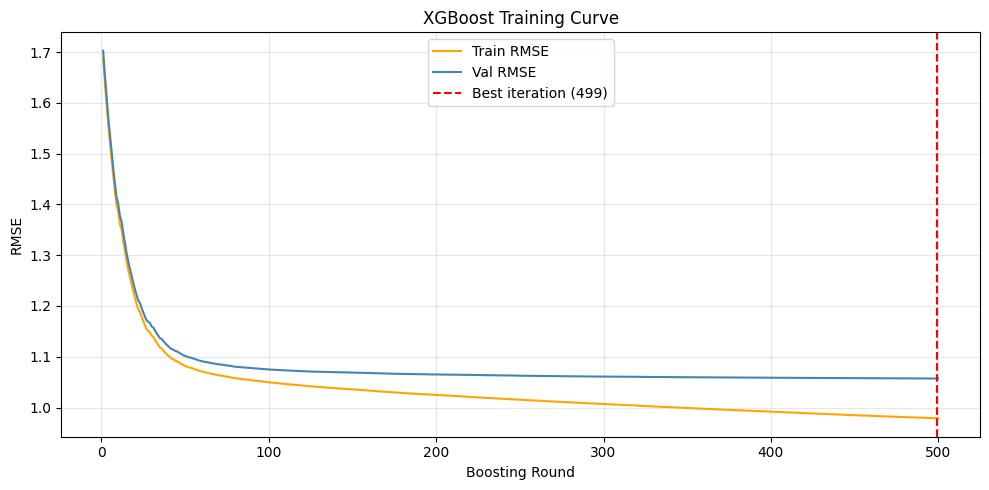

Best iteration: 499
Best validation RMSE: 1.0572


In [48]:
results = xgb_reg.evals_result()
train_rmse = results["validation_0"]["rmse"]
val_rmse   = results["validation_1"]["rmse"]

epochs = np.arange(1, len(val_rmse) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train_rmse, label="Train RMSE", color="orange")
ax.plot(epochs, val_rmse,   label="Val RMSE",   color="steelblue")
ax.axvline(xgb_reg.best_iteration, color="red", linestyle="--", label=f"Best iteration ({xgb_reg.best_iteration})")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE")
ax.set_title("XGBoost Training Curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best iteration: {xgb_reg.best_iteration}")
print(f"Best validation RMSE: {val_rmse[xgb_reg.best_iteration]:.4f}")

In [54]:
X_meta = merged[meta_cols].copy()
y      = merged["rating"].values

X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(X_meta, y, test_size=0.3, random_state=42)
X_val_b, X_test_b, y_val_b, y_test_b     = train_test_split(X_temp_b, y_temp_b, test_size=0.5, random_state=42)

for col in X_train_b.select_dtypes(include=['object']).columns:
    X_train_b[col] = X_train_b[col].astype('category')
for col in X_val_b.select_dtypes(include=['object']).columns:
    X_val_b[col] = X_val_b[col].astype('category')
for col in X_test_b.select_dtypes(include=['object']).columns:
    X_test_b[col] = X_test_b[col].astype('category')

In [51]:
xgb_baseline = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    enable_categorical=True
)

xgb_baseline.fit(
    X_train_b, y_train_b,
    eval_set=[(X_train_b, y_train_b), (X_val_b, y_val_b)],
    verbose=50
)

[0]	validation_0-rmse:1.68641	validation_1-rmse:1.70115
[50]	validation_0-rmse:1.08825	validation_1-rmse:1.10139
[100]	validation_0-rmse:1.06685	validation_1-rmse:1.08139
[150]	validation_0-rmse:1.06333	validation_1-rmse:1.07922
[200]	validation_0-rmse:1.06233	validation_1-rmse:1.07896
[250]	validation_0-rmse:1.06163	validation_1-rmse:1.07883
[300]	validation_0-rmse:1.06114	validation_1-rmse:1.07877
[350]	validation_0-rmse:1.06071	validation_1-rmse:1.07869
[388]	validation_0-rmse:1.06030	validation_1-rmse:1.07857


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

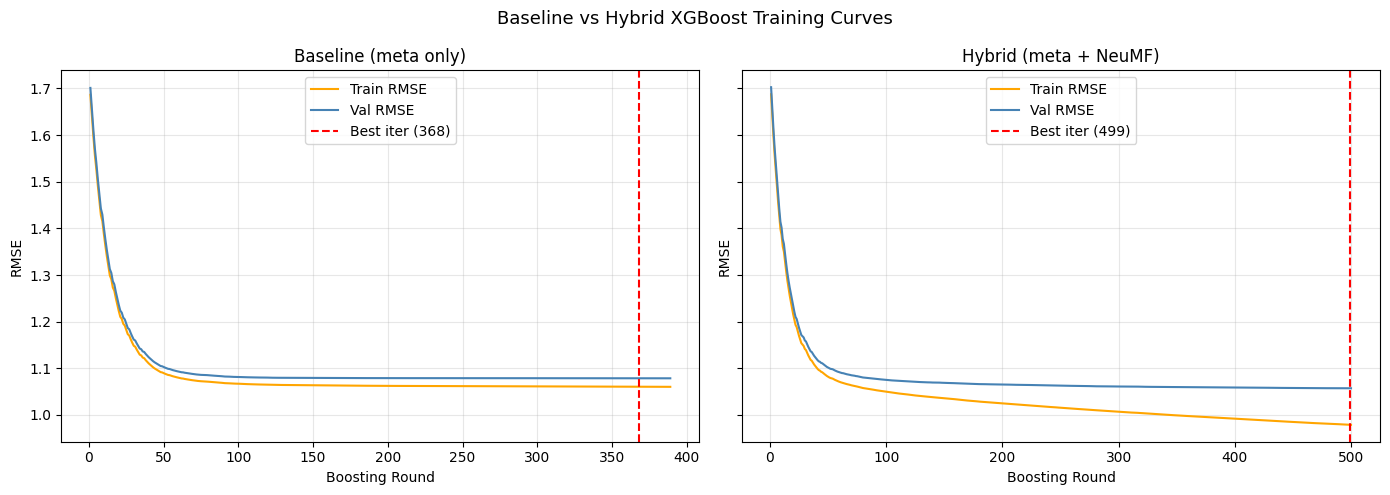

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, model, label in [
    (axes[0], xgb_baseline, "Baseline"),
    (axes[1], xgb_reg,      "Hybrid"),
]:
    res   = model.evals_result()
    train = res["validation_0"]["rmse"]
    val   = res["validation_1"]["rmse"]
    epochs = range(1, len(val) + 1)
    ax.plot(epochs, train, label="Train RMSE", color="orange")
    ax.plot(epochs, val,   label="Val RMSE",   color="steelblue")
    ax.axvline(model.best_iteration, color="red", linestyle="--",
               label=f"Best iter ({model.best_iteration})")
    ax.set_title(label)
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Baseline vs Hybrid XGBoost Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

In [59]:
def precision_recall_at_k(model, X, merged_subset, k=10, relevance_threshold=7.0):
    df_eval = merged_subset[["user", "item", "rating"]].copy().reset_index(drop=True)
    df_eval["pred"] = model.predict(X)

    precision_list = []
    recall_list    = []

    for user_id, group in df_eval.groupby("user"):
        relevant_items = set(group[group["rating"] >= relevance_threshold]["item"])
        if not relevant_items:
            continue

        top_k = group.nlargest(k, "pred")["item"].values

        hits = sum(1 for item in top_k if item in relevant_items)

        precision_list.append(hits / k)
        recall_list.append(hits / len(relevant_items))

    precision_at_k = np.mean(precision_list)
    recall_at_k    = np.mean(recall_list)
    return precision_at_k, recall_at_k

In [68]:
merged_reset = merged.reset_index(drop=True)

idx_all              = list(range(len(merged_reset)))
idx_train, idx_temp  = train_test_split(idx_all, test_size=0.3, random_state=42)
idx_val,   idx_test  = train_test_split(idx_temp, test_size=0.5, random_state=42)

merged_test = merged_reset.iloc[idx_test].reset_index(drop=True)
X_test_b    = merged_reset.iloc[idx_test][meta_cols].reset_index(drop=True)
X_test      = df_hybrid.iloc[idx_test].reset_index(drop=True)

for col in X_test_b.select_dtypes(include=['object']).columns:
    X_test_b[col] = X_test_b[col].astype('category')
for col in X_test.select_dtypes(include=['object']).columns:
    X_test[col] = X_test[col].astype('category')

K_values = [5, 10, 20]
threshold = 7.0

print(f"Relevance threshold: rating >= {threshold}")
print(f"\n{'K':<6} {'Model':<25} {'Precision@K':>12} {'Recall@K':>10}")
print("-" * 55)

for k in K_values:
    for model, X_test_data, label in [
        (xgb_baseline, X_test_b,  "Baseline"),
        (xgb_reg,      X_test,    "Hybrid"),
    ]:
        p, r = precision_recall_at_k(model, X_test_data, merged_test, k=k, relevance_threshold=threshold)
        print(f"{k:<6} {label:<25} {p:>12.4f} {r:>10.4f}")
    print()

Relevance threshold: rating >= 7.0

K      Model                      Precision@K   Recall@K
-------------------------------------------------------
5      Baseline (meta only)            0.2645     0.9917
5      Hybrid (meta + NeuMF)           0.2645     0.9917

10     Baseline (meta only)            0.1370     0.9981
10     Hybrid (meta + NeuMF)           0.1370     0.9981

20     Baseline (meta only)            0.0698     0.9997
20     Hybrid (meta + NeuMF)           0.0698     0.9997



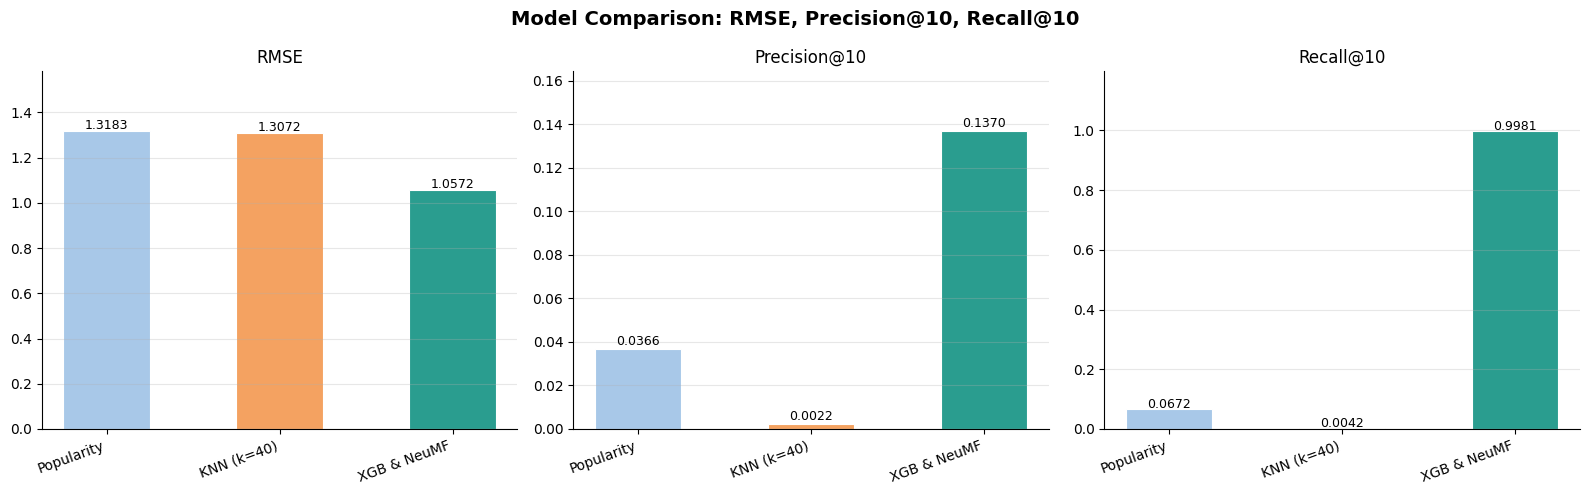

In [70]:
# comparing with baselines

models = ["Popularity", "KNN (k=40)", "XGB & NeuMF"]
colors = ["#a8c8e8", "#f4a261", "#2a9d8f"]

rmse   = [1.3183, 1.3072, 1.0572]

# Precision and Recall @ K=10
prec_k10  = [0.0366, 0.0022, 0.1370]
rec_k10   = [0.0672, 0.0042, 0.9981]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Comparison: RMSE, Precision@10, Recall@10", fontsize=14, fontweight="bold")

x = np.arange(len(models))
bar_kw = dict(width=0.5, edgecolor="white", linewidth=0.8)

# RMSE
axes[0].bar(x, rmse, color=colors, **bar_kw)
axes[0].set_title("RMSE")
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=20, ha="right")
axes[0].set_ylim(0, max(rmse) * 1.2)
for i, v in enumerate(rmse):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)

# Precision@10
axes[1].bar(x, prec_k10, color=colors, **bar_kw)
axes[1].set_title("Precision@10")
axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=20, ha="right")
axes[1].set_ylim(0, max(prec_k10) * 1.2)
for i, v in enumerate(prec_k10):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

# Recall@10
axes[2].bar(x, rec_k10, color=colors, **bar_kw)
axes[2].set_title("Recall@10")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, rotation=20, ha="right")
axes[2].set_ylim(0, max(rec_k10) * 1.2)
for i, v in enumerate(rec_k10):
    axes[2].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()